In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as st


In [5]:
# 2 Lakh rows
df = pd.read_csv("/content/drive/MyDrive/2020_Yellow_Taxi_Trip_Data.csv", nrows=2000000)

# Display the first few rows to confirm
df.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,01/01/2020 12:28:15 AM,01/01/2020 12:33:03 AM,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1.0,01/01/2020 12:35:39 AM,01/01/2020 12:43:04 AM,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1.0,01/01/2020 12:47:41 AM,01/01/2020 12:53:52 AM,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1.0,01/01/2020 12:55:23 AM,01/01/2020 01:00:14 AM,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2.0,01/01/2020 12:01:58 AM,01/01/2020 12:04:16 AM,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0


In [6]:
df['tpep_dropoff_datetime'] = pd.to_datetime(df["tpep_dropoff_datetime"])
df['tpep_pickup_datetime'] = pd.to_datetime(df["tpep_pickup_datetime"])

<ipython-input-6-61f936920b50>:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['tpep_dropoff_datetime'] = pd.to_datetime(df["tpep_dropoff_datetime"])
<ipython-input-6-61f936920b50>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['tpep_pickup_datetime'] = pd.to_datetime(df["tpep_pickup_datetime"])


In [7]:
df["duration"]  = df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]

In [8]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,duration
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.20,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.00,0.3,11.27,2.5,0 days 00:04:48
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.20,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.00,0.3,12.30,2.5,0 days 00:07:25
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.60,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.00,0.3,10.80,2.5,0 days 00:06:11
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.80,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.00,0.3,8.16,0.0,0 days 00:04:51
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.00,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.00,0.3,4.80,0.0,0 days 00:02:18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,2.0,2020-01-11 14:38:41,2020-01-11 15:20:23,1.0,14.32,1.0,N,138,89,2.0,43.5,0.0,0.5,0.00,0.00,0.3,44.30,0.0,0 days 00:41:42
1999996,2.0,2020-01-11 14:05:28,2020-01-11 14:27:30,1.0,9.21,2.0,N,93,229,1.0,52.0,0.0,0.5,12.28,6.12,0.3,73.70,2.5,0 days 00:22:02
1999997,1.0,2020-01-11 14:06:38,2020-01-11 14:24:56,1.0,9.50,1.0,N,132,56,2.0,27.0,0.0,0.5,0.00,0.00,0.3,27.80,0.0,0 days 00:18:18
1999998,1.0,2020-01-11 14:33:34,2020-01-11 15:02:54,1.0,4.80,2.0,N,226,100,2.0,52.0,2.5,0.5,0.00,12.24,0.3,67.54,2.5,0 days 00:29:20


In [9]:
df["duration"] = df["duration"].dt.total_seconds()

In [10]:
df["duration"] = df["duration"]/60

In [11]:
df.duration

,duration
0,4.800000
1,7.416667
2,6.183333
3,4.850000
4,2.300000
...,...
1999995,41.700000
1999996,22.033333
1999997,18.300000
1999998,29.333333


In [12]:
df = df[["passenger_count","payment_type","fare_amount","trip_distance","duration"]]

In [13]:
#fraction of null data
df.isnull().sum()/len(df)*100

,0
passenger_count,0.2071
payment_type,0.2071
fare_amount,0.0000
trip_distance,0.0000
duration,0.0000


### ***drop or fill depends on the fraction of data missing***
we can drop here

In [14]:
df.dropna(inplace = True)

<ipython-input-14-d1ada024d2eb>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace = True)


In [15]:
df.dtypes

,0
passenger_count,float64
payment_type,float64
fare_amount,float64
trip_distance,float64
duration,float64


### ***Passenger counts  and payment type should be int***

In [16]:
df.passenger_count = df.passenger_count.astype(int)
df.paymemt_type = df.payment_type.astype(int)

<ipython-input-16-2d94959d3879>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.passenger_count = df.passenger_count.astype(int)
<ipython-input-16-2d94959d3879>:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.paymemt_type = df.payment_type.astype(int)


In [17]:
df[df.duplicated()]


,passenger_count,payment_type,fare_amount,trip_distance,duration
2064,1,2.0,7.0,0.00,0.000000
2451,1,1.0,52.0,0.00,0.200000
2456,2,1.0,9.5,1.70,13.066667
2476,1,1.0,4.0,0.40,3.083333
3358,1,1.0,6.0,1.20,5.350000
...,...,...,...,...,...
1999988,1,2.0,4.5,0.00,4.116667
1999989,1,1.0,7.0,0.00,9.366667
1999993,1,1.0,52.0,0.05,0.233333
1999994,1,2.0,6.0,0.73,6.383333


In [18]:
len(df)


1995858

### ***out of 199656 rows, 18769 rows are duplicated***  

In [19]:
df.drop_duplicates(inplace = True)

<ipython-input-19-9ce7144259af>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace = True)


In [20]:
df = df[df["payment_type"]<3] # we need only 1 & 2 payment type

### ***Lets find outlier based on passenger count***

In [21]:
df.passenger_count.value_counts(normalize = True)

,proportion
passenger_count,
1,0.603978
2,0.190558
3,0.062194
5,0.054471
4,0.033911
6,0.033231
0,0.021635
7,0.000011
8,0.000008


## ***Following can be ignored***
6	0.033231

0	0.021635

7	0.000011

8	0.000008

9	0.000004



In [22]:
df = df[(df["passenger_count"]>0) & (df["passenger_count"]<6)]

In [23]:
df.payment_type.replace([1,2],["Card","Cash"], inplace = True)

<ipython-input-23-a80326fe3bc7>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.payment_type.replace([1,2],["Card","Cash"], inplace = True)


In [24]:
df.describe()

,passenger_count,fare_amount,trip_distance,duration
count,1.159670e+06,1.159670e+06,1.159670e+06,1.159670e+06
mean,1.671414e+00,1.593173e+01,4.017209e+00,2.069401e+01
std,1.122107e+00,1.413842e+01,4.661901e+00,8.327197e+01
min,1.000000e+00,-5.000000e+02,-2.218000e+01,-2.770367e+03
25%,1.000000e+00,8.000000e+00,1.300000e+00,8.333333e+00
50%,1.000000e+00,1.150000e+01,2.300000e+00,1.343333e+01
75%,2.000000e+00,1.800000e+01,4.510000e+00,2.033333e+01
max,5.000000e+00,1.238000e+03,2.592200e+02,4.168000e+03


###***we can see outliers are present as huge difference b/w 75% and max***
#####***also -ve fair amount isn't possible***
#####***also trip distance & duration can't be 0***

In [25]:
df = df[df["trip_distance"]>0]
df = df[df["fare_amount"]>0]
df = df[df["duration"]>0]

(array([1.147425e+06, 6.200000e+02, 6.400000e+01, 1.200000e+01,
        5.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 1.000000e+00]),
 array([1.000000e-02, 1.238090e+02, 2.476080e+02, 3.714070e+02,
        4.952060e+02, 6.190050e+02, 7.428040e+02, 8.666030e+02,
        9.904020e+02, 1.114201e+03, 1.238000e+03]),
 <BarContainer object of 10 artists>)

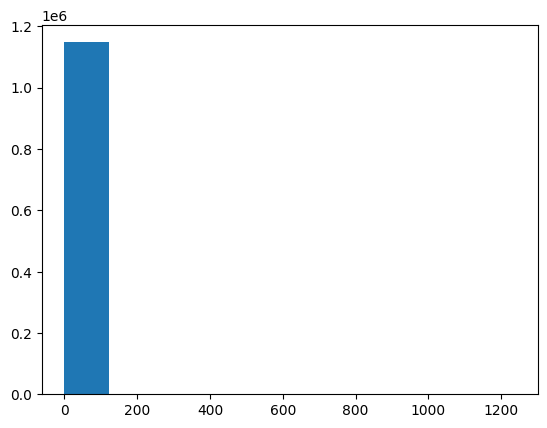

In [26]:
plt.hist(df["fare_amount"])

###***Therefore, outliers from 100 till 400***

In [27]:
### we will use interquarlile range
for col in ['trip_distance', 'fare_amount','duration']:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3-q1
  upper_limit = q3 + 1.5*iqr
  lower_limit = q1 - 1.5*iqr

  df = df[(df[col]>lower_limit) & (df[col]<upper_limit)]

(array([  1576.,  87118., 194439., 207628., 194083., 107623.,  72400.,
         49183.,  33006.,  28025.]),
 array([1.0000e-02, 2.6090e+00, 5.2080e+00, 7.8070e+00, 1.0406e+01,
        1.3005e+01, 1.5604e+01, 1.8203e+01, 2.0802e+01, 2.3401e+01,
        2.6000e+01]),
 <BarContainer object of 10 artists>)

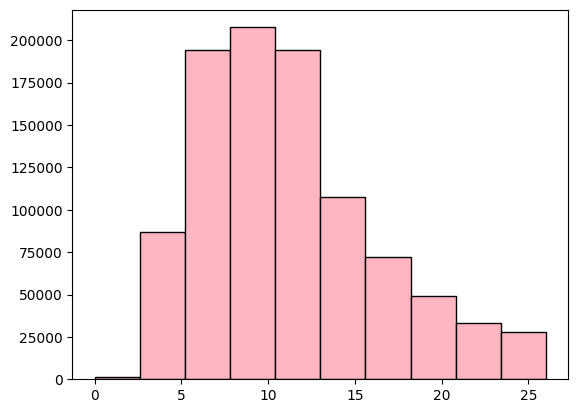

In [28]:
plt.hist(df["fare_amount"], color = 'lightpink', edgecolor ='black')

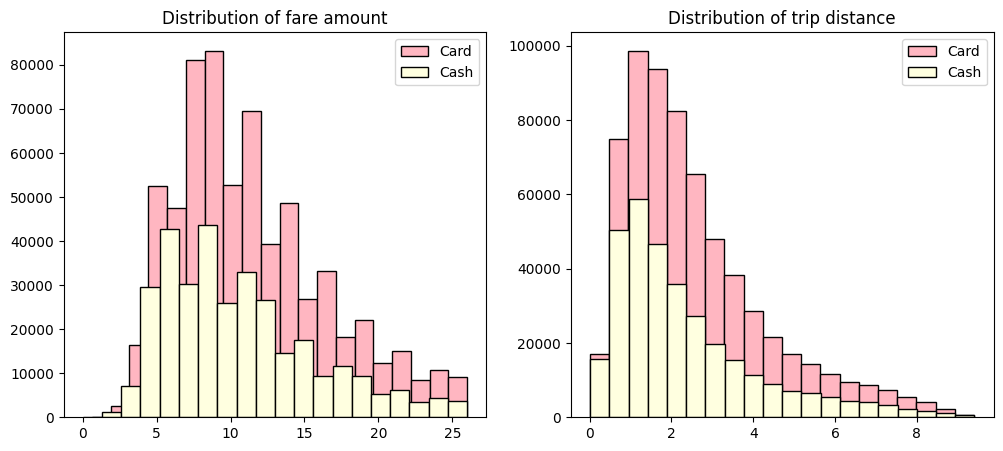

In [29]:
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
plt.title("Distribution of fare amount")
plt.hist(df[df['payment_type']=='Card']['fare_amount'], label = 'Card',bins =20, edgecolor = 'black', color = 'lightpink')

plt.hist(df[df['payment_type']=='Cash']['fare_amount'], label = 'Cash',bins = 20, edgecolor = 'black', color = 'lightyellow')
plt.legend()

plt.subplot(1,2,2)
plt.title("Distribution of trip distance")
plt.hist(df[df['payment_type']=='Card']['trip_distance'], label = 'Card',bins =20, edgecolor = 'black', color = 'lightpink')

plt.hist(df[df['payment_type']=='Cash']['trip_distance'], label = 'Cash',bins = 20, edgecolor = 'black', color = 'lightyellow')
plt.legend()

###***card payment preference increase with larger difference***


In [30]:
df.groupby('payment_type').agg({'fare_amount':['mean','std'],'trip_distance':['mean','std']})

fare_amount           trip_distance          
                    mean       std          mean       std
payment_type                                              
Card           11.487915  5.128570      2.568821  1.749702
Cash           10.665859  5.092928      2.330462  1.755533

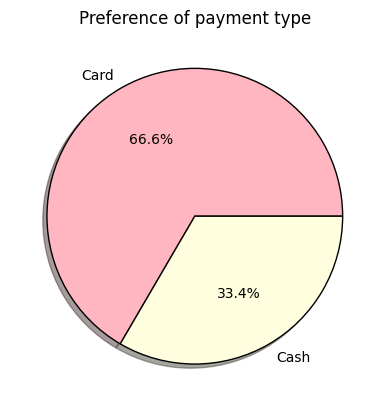

In [42]:
plt.title("Preference of payment type")
plt.pie(df["payment_type"].value_counts(normalize = True), \
        labels = df['payment_type'].value_counts().index, \
        colors = ["lightpink","lightyellow"],\
        shadow =True, \
        wedgeprops={'edgecolor': 'black'},\
                    autopct='%1.1f%%')
plt.show()

In [32]:
passenger_count = df.groupby(["payment_type","passenger_count"])[["passenger_count"]].count()
passenger_count


passenger_count
payment_type passenger_count                 
Card         1                         404103
             2                         134716
             3                          45162
             4                          22452
             5                          42874
Cash         1                         207179
             2                          65500
             3                          21942
             4                          13872
             5                          17281

In [33]:
# Group by payment_type and passenger_count, and count occurrences
passenger_count = df.groupby(["payment_type", "passenger_count"])[["passenger_count"]].count()

# Rename the column for convenience
passenger_count.rename(columns={'passenger_count': 'count'}, inplace=True)

# Calculate percentage for each group
passenger_count["perc"] = (passenger_count["count"] / passenger_count["count"].sum()) * 100

# Display the result
passenger_count


count       perc
payment_type passenger_count                   
Card         1                404103  41.443019
             2                134716  13.815878
             3                 45162   4.631615
             4                 22452   2.302578
             5                 42874   4.396968
Cash         1                207179  21.247363
             2                 65500   6.717391
             3                 21942   2.250275
             4                 13872   1.422651
             5                 17281   1.772263

In [34]:
df1 = pd.DataFrame(columns = ["payment_type",1,2,3,4,5])

In [35]:
df1
df1["payment_type"] = ["Card (out of 74.3% )","Cash(out of25.7%)"]
df1

,payment_type,1,2,3,4,5
0,Card (out of 74.3% ),NaN,NaN,NaN,NaN,NaN
1,Cash(out of25.7%),NaN,NaN,NaN,NaN,NaN


In [36]:
df1.iloc[0,1:] = passenger_count.iloc[0:5,-1]
df1.iloc[1,1:] = passenger_count.iloc[5:,-1]
df1

,payment_type,1,2,3,4,5
0,Card (out of 74.3% ),41.443019,13.815878,4.631615,2.302578,4.396968
1,Cash(out of25.7%),21.247363,6.717391,2.250275,1.422651,1.772263


###***stacked barchart***

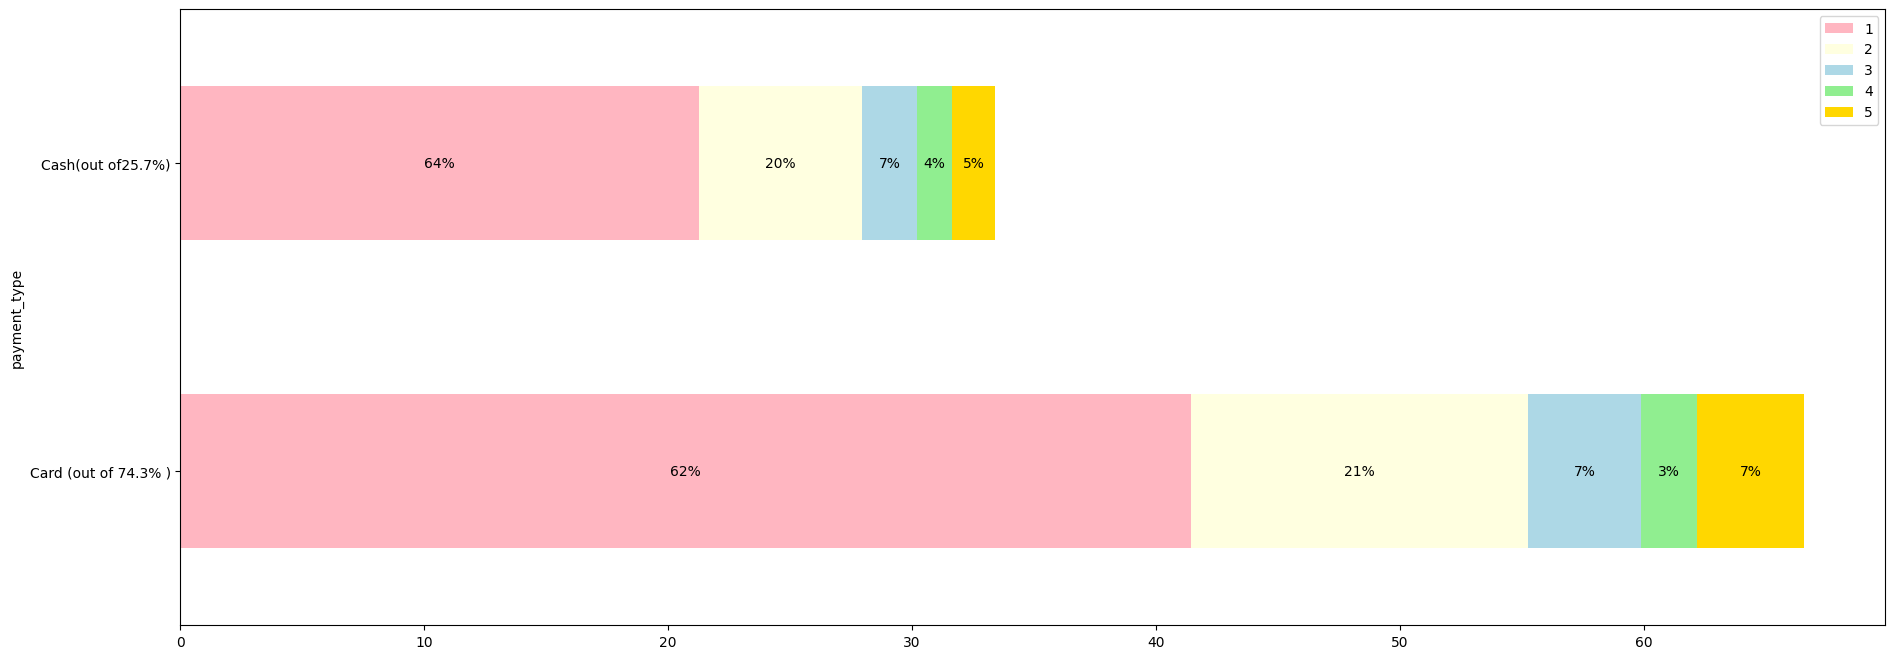

In [37]:
import matplotlib.pyplot as plt

# Assuming df is already defined and contains the necessary data
fig, ax = plt.subplots(figsize=(22, 8))

# Plot the stacked bar chart
df1.plot(x="payment_type", kind="barh", stacked=True, color=["lightpink", "lightyellow", "lightblue", 'lightgreen', 'gold'], ax=ax)

# Add percentage values on each bar
# Exclude the 'payment_type' column from the sum calculation to avoid the TypeError
total = df1.drop(columns=['payment_type']).sum(axis=1)  # Compute the total for each row (to normalize)
for i, p in enumerate(ax.patches): # Enumerate to get the index of the patch
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()

    # Calculate the percentage of the total, use index 'i' to access total
    percentage = (width / total.iloc[i % len(total)]) * 100 # Use modulo to wrap around total if needed

    ax.text(x + width / 2, y + height / 2, '{:.0f}%'.format(percentage),
            horizontalalignment='center',
            verticalalignment='center')

plt.show()

### ***null hypothesis*** : there is no difference in avg fare b/w customer using card and customer using cash  ***Alternative hypothesis*** : there is difference in avg fare b/w customer using card and customer using cash

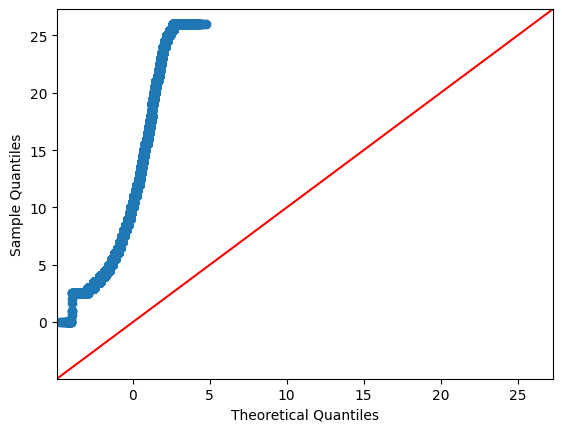

In [38]:
# qq plot
sm.qqplot(df["fare_amount"], line='45')
plt.show()

###***not normally distributed data hence we use t0test, also we don't have population standard deviation***

In [39]:
card_sample = df[df["payment_type"]=="Card"]["fare_amount"]
cash_sample = df[df["payment_type"]=="Cash"]["fare_amount"]

In [40]:
t_stats, p_value = st.ttest_ind(a= card_sample, b= cash_sample, equal_var = False)
print("t-statistic:", t_stats)
print("p-value:", p_value)

t-statistic: 75.00325711991626
p-value: 0.0
